In [379]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
!pip install openpyxl
!pip install seaborn --upgrade


pd.set_option('display.max_columns', None)
df_bank=pd.read_csv("/Users/mari/Desktop/Data Analytics/Python for Data/DatosProyecto/bank-additional.csv")

#Se obtiene una visión general del contenido del dataset: Número de columnas, filas, tipo de datos

df_bank.head()
df_bank.info(30)

<class 'pandas.DataFrame'>
RangeIndex: 43000 entries, 0 to 42999
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      43000 non-null  int64  
 1   age             37880 non-null  float64
 2   job             42655 non-null  str    
 3   marital         42915 non-null  str    
 4   education       41193 non-null  str    
 5   default         34019 non-null  float64
 6   housing         41974 non-null  float64
 7   loan            41974 non-null  float64
 8   contact         43000 non-null  str    
 9   duration        43000 non-null  int64  
 10  campaign        43000 non-null  int64  
 11  pdays           43000 non-null  int64  
 12  previous        43000 non-null  int64  
 13  poutcome        43000 non-null  str    
 14  emp.var.rate    43000 non-null  float64
 15  cons.price.idx  42529 non-null  str    
 16  cons.conf.idx   43000 non-null  str    
 17  euribor3m       33744 non-null  str    
 1

In [380]:
# Se ven las referencias estadísticas
df_bank.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,43000.0,20651.099047,11868.770913,0.000,10381.75000,20642.5000,30930.25000,41187.000
age,37880.0,39.977112,10.437957,17.000,32.00000,38.0000,47.00000,98.000
default,34019.0,0.000088,0.009390,0.000,0.00000,0.0000,0.00000,1.000
housing,41974.0,0.535998,0.498708,0.000,0.00000,1.0000,1.00000,1.000
loan,41974.0,0.155620,0.362499,0.000,0.00000,0.0000,0.00000,1.000
duration,43000.0,257.739279,258.666033,0.000,102.00000,179.0000,319.00000,4918.000
campaign,43000.0,2.567233,2.772294,1.000,1.00000,2.0000,3.00000,56.000
pdays,43000.0,962.330953,187.260394,0.000,999.00000,999.0000,999.00000,999.000
previous,43000.0,0.174023,0.497366,0.000,0.00000,0.0000,0.00000,7.000
emp.var.rate,43000.0,0.077128,1.573898,-3.400,-1.80000,1.1000,1.40000,1.400


In [381]:
#Se elimina la columna Unnamed: 0 al ser un indice anterior
df_bank.drop("Unnamed: 0", axis=1, inplace=True)

In [382]:
# Se verifica si las columnas tienen espacio
for col in df_bank.columns:
    print(f"'{col}'")

'age'
'job'
'marital'
'education'
'default'
'housing'
'loan'
'contact'
'duration'
'campaign'
'pdays'
'previous'
'poutcome'
'emp.var.rate'
'cons.price.idx'
'cons.conf.idx'
'euribor3m'
'nr.employed'
'y'
'date'
'latitude'
'longitude'
'id_'


In [383]:
# Se verifica cuantos valores nulos tiene cada columna
df_bank.isnull()
df_bank.isnull().sum()

age               5120
job                345
marital             85
education         1807
default           8981
housing           1026
loan              1026
contact              0
duration             0
campaign             0
pdays                0
previous             0
poutcome             0
emp.var.rate         0
cons.price.idx     471
cons.conf.idx        0
euribor3m         9256
nr.employed          0
y                    0
date               248
latitude             0
longitude            0
id_                  0
dtype: int64

In [384]:
# Porcentaje de datos faltantes en cada columna
df_bank.isna().sum()/(df_bank.shape[0])*100

age               11.906977
job                0.802326
marital            0.197674
education          4.202326
default           20.886047
housing            2.386047
loan               2.386047
contact            0.000000
duration           0.000000
campaign           0.000000
pdays              0.000000
previous           0.000000
poutcome           0.000000
emp.var.rate       0.000000
cons.price.idx     1.095349
cons.conf.idx      0.000000
euribor3m         21.525581
nr.employed        0.000000
y                  0.000000
date               0.576744
latitude           0.000000
longitude          0.000000
id_                0.000000
dtype: float64

In [385]:
# Se rellena los datos faltantes con la mediana porque no se ve afectada por los outliers.
# Se convierte a int al ser variable de edad.
df_bank["age"] = df_bank["age"].fillna(df_bank["age"].median())
df_bank["age"] = df_bank["age"].astype(int)

In [386]:
# Se verifica que la columna age no tenga datos faltantes
df_bank["age"].isna().sum()

np.int64(0)

In [387]:
# Se rellena la columna job con desconocido al ser un porcentaje bajo de valores nulos
df_bank["job"] = df_bank["job"].fillna("Desconocido")

# Se verifica que la columna job no tenga datos faltantes
df_bank["job"].isna().sum()

np.int64(0)

In [388]:
#Para evitar crear una categoria nueva y al ser un porcentaje bajo, se rellena con la moda para mantener la distribucion real de los datos.
# Se pide coger el primer valor de la serie moda
df_bank["education"] = df_bank["education"].fillna(df_bank["education"].mode()[0])

# Se verifica que la columna education no tenga datos faltantes
df_bank["education"].isna().sum()

np.int64(0)

In [389]:
# Dado que en la columna default solo 3 casos son 1, y 20% son nulos hace que el dataset sea muy desbalanceado y aporte valor significativo.
len(df_bank[df_bank['default'] == 1])


3

In [390]:
#Mantener la columna con tantos nulos y tan poco valor informativo podría introducir ruido, confundir al modelo y reducir la precisión. Precisamente, para evitar eso se elimina.
df_bank= df_bank.drop(columns='default')

In [391]:
# Se rellena la columna job con desconocido al ser un porcentaje bajo de valores nulos
df_bank["marital"] = df_bank["marital"].fillna("Desconocido")
# Se verifica que la columna marital no tenga datos faltantes
df_bank["marital"].isna().sum()

np.int64(0)

In [392]:
#las columnas housing y loan son columnas binarias con muy pocos nulos (~2%) decido rellenar los nulos con el valor mas frecuente (moda).
# Para hacer los datos mas legibles, reemplazo los floats con No y Si.
for col in ["housing", "loan"]:
    # Rellenar nulos con la moda
    df_bank[col] = df_bank[col].fillna(df_bank[col].mode()[0])
# Convertir 0.0/1.0 a "No"/"Si"
    df_bank[col] = df_bank[col].map({0.0: "No", 1.0: "Si"})

In [393]:
# Se ve los tipos de datos que tiene cada columna
df_bank.dtypes

age                 int64
job                   str
marital               str
education             str
housing               str
loan                  str
contact               str
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome              str
emp.var.rate      float64
cons.price.idx        str
cons.conf.idx         str
euribor3m             str
nr.employed           str
y                     str
date                  str
latitude          float64
longitude         float64
id_                   str
dtype: object

In [394]:
# Se verifica cuantos duplicados hay
df_bank.duplicated().sum()

np.int64(0)

In [395]:
# Lista de columnas a convertir
cols_to_convert = ["cons.price.idx", "cons.conf.idx", "euribor3m"]

# Reemplazar comas por puntos y convertir a float
for col in cols_to_convert:
    # Reemplazar comas por puntos
    df_bank[col] = df_bank[col].str.replace(",", ".", regex=False)
    
    # Convertir a float, con 'coerce' para convertir los errores a NaN
    df_bank[col] = pd.to_numeric(df_bank[col], errors="coerce")

cols_to_convert

['cons.price.idx', 'cons.conf.idx', 'euribor3m']

In [396]:
# Se eliminan las filas con valores nulos en la columna 'cons.price.idx' por tener menos de 1% de valores nulos. No afecta a la calidad del dataset
df_bank = df_bank[df_bank["cons.price.idx"].notna()]

# Se verifica que la columna cons.price.idx no tenga datos faltantes
df_bank["cons.price.idx"].isna().sum()

np.int64(0)

In [397]:
# Los valores nulos representan una quinta parte del dataset, por lo tanto lo relleno con la mediana para que no distorsione la distribución

df_bank["euribor3m"] = df_bank["euribor3m"].fillna(df_bank["euribor3m"].median())

# Se verifica que la columna euribor3m no tenga datos faltantes
df_bank["euribor3m"].isna().sum()

np.int64(0)

In [398]:
# Se inspecciona que columna queda con datos faltantes
df_bank.isna().sum()

age                 0
job                 0
marital             0
education           0
housing             0
loan                0
contact             0
duration            0
campaign            0
pdays               0
previous            0
poutcome            0
emp.var.rate        0
cons.price.idx      0
cons.conf.idx       0
euribor3m           0
nr.employed         0
y                   0
date              244
latitude            0
longitude           0
id_                 0
dtype: int64

In [399]:
# Se crea un diccionario para cambiar los nombres de los meses en la columnda date al formato número.
meses = {
    "enero": "01", "febrero": "02", "marzo": "03",
    "abril": "04", "mayo": "05", "junio": "06",
    "julio": "07", "agosto": "08", "septiembre": "09",
    "octubre": "10", "noviembre": "11", "diciembre": "12"
}

for mes, num in meses.items():
    df_bank["date"] = df_bank["date"].str.replace(mes, num)



In [400]:
# Se convierte la columna date a tipo datetime
df_bank["date"] = pd.to_datetime(df_bank["date"], format="%d-%m-%Y", errors="coerce")

In [401]:
# Los valores nulos al representar menos del 1% del dataset se eliminan ya que este acto no altera la integridad ni relevancia de los datos restantes.
df_bank = df_bank[df_bank["date"].notna()]
# Se verifica que la columna date no tenga datos faltantes
df_bank["date"].isna().sum()

np.int64(0)

In [402]:
# Extraer el mes numérico y año directamente desde la columna 'date'
df_bank["contact_month"] = df_bank["date"].dt.month 
df_bank["contact_year"] = df_bank["date"].dt.year  

In [403]:
# Se eliminan estas columnas al no tener relevancia en el análisis e intrepretación de los datos
df_bank = df_bank.drop(["latitude", "longitude"], axis=1)


In [404]:
# Se reemplaza el no por No y el yes por el Si para tener los datos de forma uniforme
df_bank["y"] = df_bank["y"].map({"no": "No", "yes": "Si"})
df_bank["y"]

0        No
1        No
2        No
3        No
4        No
         ..
42995    Si
42996    No
42997    No
42998    No
42999    No
Name: y, Length: 42285, dtype: str

In [405]:
#El número de empleados debe de ser un valor entero. Para esto primero hay que reemplazar la coma por el punto
df_bank["nr.employed"] = df_bank["nr.employed"].str.replace(",", ".", regex=False)


In [406]:
# Ahora convertir el string a número
df_bank["nr.employed"] = pd.to_numeric(df_bank["nr.employed"], errors="coerce")


In [407]:
# Ahora a número entero
df_bank["nr.employed"] = df_bank["nr.employed"].astype(int)

In [408]:
# Resultado del total de columnas y filas tras eliminar algunas.
df_bank.shape

(42285, 22)

In [409]:
# se procede a abrir el segundo dataset para su limpieza y transformación
archivo = "/Users/mari/Desktop/Data Analytics/Python for Data/DatosProyecto/customer-details.xlsx"

# Se abren todas las hojas del archivo excel
df_customer_details1 = pd.read_excel(archivo, sheet_name="2012")
df_customer_details2 = pd.read_excel(archivo, sheet_name="2013")
df_customer_details3 = pd.read_excel(archivo, sheet_name="2014")

In [410]:
# Se obtiene información del contenido de la hoja 1
df_customer_details1.head()


,Unnamed: 0,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth,ID
0,0,161770,1,0,2012-04-04,29,089b39d8-e4d0-461b-87d4-814d71e0e079
1,1,85477,1,1,2012-12-30,7,e9d37224-cb6f-4942-98d7-46672963d097
2,2,147233,1,1,2012-02-02,5,3f9f49b5-e410-4948-bf6e-f9244f04918b
3,3,121393,1,2,2012-12-21,29,9991fafb-4447-451a-8be2-b0df6098d13e
4,4,63164,1,2,2012-06-20,20,eca60b76-70b6-4077-80ba-bc52e8ebb0eb


In [411]:
# Se obtiene información del contenido de la hoja 2
df_customer_details2.head()

,Unnamed: 0,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth,ID
0,0,82407,0,1,2013-10-07,29,ef81336c-e41a-46d0-8a30-5d4ac3b836be
1,1,24877,0,0,2013-04-21,32,50b224ac-84b4-42a7-aba9-3e1d1d620479
2,2,78839,1,0,2013-11-25,21,9cb15c53-b647-464a-add9-09cdae04897c
3,3,113859,1,1,2013-01-06,12,f8aaf334-949d-4943-a214-b64fe9c088b4
4,4,147317,0,0,2013-07-10,14,885fe85a-3718-4760-a32a-a57628cf7528


In [412]:
# Se obtiene información del contenido de la hoja 3
df_customer_details3.head()

,Unnamed: 0,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth,ID
0,0,168812,1,1,2014-06-10,27,4d6c811c-0f24-4a73-b374-2ebd1f80d46e
1,1,108615,2,1,2014-04-05,24,eef0f24f-cbdb-4c67-b371-09d7bc59695e
2,2,179041,0,2,2014-09-22,4,bbfdcedd-199d-4927-94bb-5dad051ff471
3,3,116639,2,2,2014-08-16,3,e8ebb67d-4ee1-4615-b701-eefe3af607eb
4,4,49537,0,1,2014-09-05,28,f7f79ace-0024-4505-a401-f340946f0942


In [413]:
# Se verifica si las columnas tienen espacio
for col in df_customer_details1.columns:
    print(f"'{col}'")

'Unnamed: 0'
'Income'
'Kidhome'
'Teenhome'
'Dt_Customer'
'NumWebVisitsMonth'
'ID'


In [414]:
# Se borra la columna Unnamed: 0 de todas las hojas ya que es un índice antiguo guardado como columna y no sirve para el análisis.
df_customer_details1 = df_customer_details1.drop("Unnamed: 0", axis=1)
df_customer_details2 = df_customer_details2.drop("Unnamed: 0", axis=1)
df_customer_details3 = df_customer_details3.drop("Unnamed: 0", axis=1)

In [415]:
# Se obtiene información del total de columnas, filas, tipos de datos
df_customer_details3.info()

<class 'pandas.DataFrame'>
RangeIndex: 14090 entries, 0 to 14089
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Income             14090 non-null  int64         
 1   Kidhome            14090 non-null  int64         
 2   Teenhome           14090 non-null  int64         
 3   Dt_Customer        14090 non-null  datetime64[us]
 4   NumWebVisitsMonth  14090 non-null  int64         
 5   ID                 14090 non-null  str           
dtypes: datetime64[us](1), int64(4), str(1)
memory usage: 660.6 KB


In [416]:
#Al tener las tres hojas de excel las mismas columnas y tipo de datos se procede a concatenarlas.
df_customer_details_final = pd.concat([
    df_customer_details1,
    df_customer_details2,
    df_customer_details3
], axis=0)

In [417]:
# Se crea un diccionario para reemplazar los meses en inglès al español
meses_es = {
    "January": "enero", "February": "febrero", "March": "marzo",
    "April": "abril", "May": "mayo", "June": "junio",
    "July": "julio", "August": "agosto", "September": "septiembre",
    "October": "octubre", "November": "noviembre", "December": "diciembre"
}

df_customer_details_final["customer_month_name"] = df_customer_details_final["Dt_Customer"].dt.month_name().map(meses_es)

In [418]:
# Se ve si los cambios se han realizado correctamente
df_customer_details_final

,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth,ID,customer_month_name
0,161770,1,0,2012-04-04,29,089b39d8-e4d0-461b-87d4-814d71e0e079,abril
1,85477,1,1,2012-12-30,7,e9d37224-cb6f-4942-98d7-46672963d097,diciembre
2,147233,1,1,2012-02-02,5,3f9f49b5-e410-4948-bf6e-f9244f04918b,febrero
3,121393,1,2,2012-12-21,29,9991fafb-4447-451a-8be2-b0df6098d13e,diciembre
4,63164,1,2,2012-06-20,20,eca60b76-70b6-4077-80ba-bc52e8ebb0eb,junio
...,...,...,...,...,...,...,...
14085,156980,1,2,2014-05-17,7,5f432048-d515-4bb5-9c94-62db451f88d4,mayo
14086,139820,0,0,2014-09-29,1,993bbbd6-4dbc-4a40-a408-f91f8462bee6,septiembre
14087,78470,2,2,2014-10-28,12,d6271666-319d-42c8-a741-cb22bf2c2093,octubre
14088,144218,0,1,2014-07-01,9,f67fbfa8-6573-414d-a805-b26a2f1b1ceb,julio


In [419]:
# Se extrae el año de la columna de fechas Dt_Customer usando .dt.year y se guarda en una nueva columna llamada customer_year.
df_customer_details_final["customer_year"] = df_customer_details_final["Dt_Customer"].dt.year
df_customer_details_final

,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth,ID,customer_month_name,customer_year
0,161770,1,0,2012-04-04,29,089b39d8-e4d0-461b-87d4-814d71e0e079,abril,2012
1,85477,1,1,2012-12-30,7,e9d37224-cb6f-4942-98d7-46672963d097,diciembre,2012
2,147233,1,1,2012-02-02,5,3f9f49b5-e410-4948-bf6e-f9244f04918b,febrero,2012
3,121393,1,2,2012-12-21,29,9991fafb-4447-451a-8be2-b0df6098d13e,diciembre,2012
4,63164,1,2,2012-06-20,20,eca60b76-70b6-4077-80ba-bc52e8ebb0eb,junio,2012
...,...,...,...,...,...,...,...,...
14085,156980,1,2,2014-05-17,7,5f432048-d515-4bb5-9c94-62db451f88d4,mayo,2014
14086,139820,0,0,2014-09-29,1,993bbbd6-4dbc-4a40-a408-f91f8462bee6,septiembre,2014
14087,78470,2,2,2014-10-28,12,d6271666-319d-42c8-a741-cb22bf2c2093,octubre,2014
14088,144218,0,1,2014-07-01,9,f67fbfa8-6573-414d-a805-b26a2f1b1ceb,julio,2014


In [420]:
# Se convierte la columna Income a tipo numérico. Los valores no convertibles se reemplazan por NaN gracias a errors="coerce".
df_customer_details_final["Income"] = pd.to_numeric(df_customer_details_final["Income"], errors="coerce")
# Se cambia el tipo de dato a float
df_customer_details_final["Income"] = df_customer_details_final["Income"].astype(float)
df_customer_details_final["Income"]

0        161770.0
1         85477.0
2        147233.0
3        121393.0
4         63164.0
           ...   
14085    156980.0
14086    139820.0
14087     78470.0
14088    144218.0
14089    115155.0
Name: Income, Length: 43170, dtype: float64

In [421]:
# Se renombran las columnas id_ e ID a id para luego facilitar su concatenación
df_bank = df_bank.rename(columns={"id_": "id"})
df_customer_details_final = df_customer_details_final.rename(columns={"ID": "id"})
df_bank 
df_customer_details_final 

,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth,id,customer_month_name,customer_year
0,161770.0,1,0,2012-04-04,29,089b39d8-e4d0-461b-87d4-814d71e0e079,abril,2012
1,85477.0,1,1,2012-12-30,7,e9d37224-cb6f-4942-98d7-46672963d097,diciembre,2012
2,147233.0,1,1,2012-02-02,5,3f9f49b5-e410-4948-bf6e-f9244f04918b,febrero,2012
3,121393.0,1,2,2012-12-21,29,9991fafb-4447-451a-8be2-b0df6098d13e,diciembre,2012
4,63164.0,1,2,2012-06-20,20,eca60b76-70b6-4077-80ba-bc52e8ebb0eb,junio,2012
...,...,...,...,...,...,...,...,...
14085,156980.0,1,2,2014-05-17,7,5f432048-d515-4bb5-9c94-62db451f88d4,mayo,2014
14086,139820.0,0,0,2014-09-29,1,993bbbd6-4dbc-4a40-a408-f91f8462bee6,septiembre,2014
14087,78470.0,2,2,2014-10-28,12,d6271666-319d-42c8-a741-cb22bf2c2093,octubre,2014
14088,144218.0,0,1,2014-07-01,9,f67fbfa8-6573-414d-a805-b26a2f1b1ceb,julio,2014


In [422]:
# Se identifican los indices de las columnas
cols = list(df_customer_details_final.columns)

# Se quita la columna de su posición actual para ponerla al lado de customer_month_name y sea mas fácil ver las fechas juntas
cols.remove("Dt_Customer")

# Se busca la posición donde se quiere insertar
pos = cols.index("customer_month_name")

# Se inserta en la posición
cols.insert(pos, "Dt_Customer")

# Se reordena el dataframe
df_customer_details_final  = df_customer_details_final [cols]
df_customer_details_final

,Income,Kidhome,Teenhome,NumWebVisitsMonth,id,Dt_Customer,customer_month_name,customer_year
0,161770.0,1,0,29,089b39d8-e4d0-461b-87d4-814d71e0e079,2012-04-04,abril,2012
1,85477.0,1,1,7,e9d37224-cb6f-4942-98d7-46672963d097,2012-12-30,diciembre,2012
2,147233.0,1,1,5,3f9f49b5-e410-4948-bf6e-f9244f04918b,2012-02-02,febrero,2012
3,121393.0,1,2,29,9991fafb-4447-451a-8be2-b0df6098d13e,2012-12-21,diciembre,2012
4,63164.0,1,2,20,eca60b76-70b6-4077-80ba-bc52e8ebb0eb,2012-06-20,junio,2012
...,...,...,...,...,...,...,...,...
14085,156980.0,1,2,7,5f432048-d515-4bb5-9c94-62db451f88d4,2014-05-17,mayo,2014
14086,139820.0,0,0,1,993bbbd6-4dbc-4a40-a408-f91f8462bee6,2014-09-29,septiembre,2014
14087,78470.0,2,2,12,d6271666-319d-42c8-a741-cb22bf2c2093,2014-10-28,octubre,2014
14088,144218.0,0,1,9,f67fbfa8-6573-414d-a805-b26a2f1b1ceb,2014-07-01,julio,2014


In [423]:
#se combinan ambos DataFrames usando la columna id como clave. Solo se combinan las filas donde el id coincide en ambos.
df_final = df_bank.merge(
    df_customer_details_final,
    on="id",
    how="inner"
)
df_final. sample(100)
df_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 42285 entries, 0 to 42284
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   age                  42285 non-null  int64         
 1   job                  42285 non-null  str           
 2   marital              42285 non-null  str           
 3   education            42285 non-null  str           
 4   housing              42285 non-null  str           
 5   loan                 42285 non-null  str           
 6   contact              42285 non-null  str           
 7   duration             42285 non-null  int64         
 8   campaign             42285 non-null  int64         
 9   pdays                42285 non-null  int64         
 10  previous             42285 non-null  int64         
 11  poutcome             42285 non-null  str           
 12  emp.var.rate         42285 non-null  float64       
 13  cons.price.idx       42285 non-null  float

In [424]:
# Se establece la columna id como índice del nuevo dataframe.
df_final.set_index("id", inplace=True)
df_final 

,age,job,marital,education,housing,loan,contact,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,date,contact_month,contact_year,Income,Kidhome,Teenhome,NumWebVisitsMonth,Dt_Customer,customer_month_name,customer_year
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,
089b39d8-e4d0-461b-87d4-814d71e0e079,38,housemaid,MARRIED,basic.4y,No,No,telephone,261,1,999,0,NONEXISTENT,1.1,93.994,-36.4,4.857,5191,No,2019-08-02,8,2019,161770.0,1,0,29,2012-04-04,abril,2012
e9d37224-cb6f-4942-98d7-46672963d097,57,services,MARRIED,high.school,No,No,telephone,149,1,999,0,NONEXISTENT,1.1,93.994,-36.4,4.857,5191,No,2016-09-14,9,2016,85477.0,1,1,7,2012-12-30,diciembre,2012
3f9f49b5-e410-4948-bf6e-f9244f04918b,37,services,MARRIED,high.school,Si,No,telephone,226,1,999,0,NONEXISTENT,1.1,93.994,-36.4,4.857,5191,No,2019-02-15,2,2019,147233.0,1,1,5,2012-02-02,febrero,2012
9991fafb-4447-451a-8be2-b0df6098d13e,40,admin.,MARRIED,basic.6y,No,No,telephone,151,1,999,0,NONEXISTENT,1.1,93.994,-36.4,4.857,5191,No,2015-11-29,11,2015,121393.0,1,2,29,2012-12-21,diciembre,2012
eca60b76-70b6-4077-80ba-bc52e8ebb0eb,56,services,MARRIED,high.school,No,Si,telephone,307,1,999,0,NONEXISTENT,1.1,93.994,-36.4,4.857,5191,No,2017-01-29,1,2017,63164.0,1,2,20,2012-06-20,junio,2012
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4eed05de-2a98-4227-b488-32122009b638,38,admin.,MARRIED,university.degree,No,No,cellular,618,2,999,0,NONEXISTENT,1.4,93.444,-36.1,4.857,5228,Si,2015-10-13,10,2015,68672.0,0,2,22,2014-03-08,marzo,2014
0f0aca88-4088-4fe2-905f-44fb675d9493,34,technician,MARRIED,professional.course,Si,Si,cellular,42,7,999,0,NONEXISTENT,-0.1,93.200,-42.0,4.857,5195,No,2018-03-17,3,2018,73578.0,0,2,26,2014-03-11,marzo,2014
cadadd4b-7ee5-4019-b13a-ca01bb67ca5b,38,blue-collar,SINGLE,basic.6y,Si,No,cellular,391,2,999,0,NONEXISTENT,1.4,93.918,-42.7,4.857,5228,No,2016-09-15,9,2016,9816.0,2,2,31,2014-09-18,septiembre,2014


In [425]:
df_final.info()

<class 'pandas.DataFrame'>
Index: 42285 entries, 089b39d8-e4d0-461b-87d4-814d71e0e079 to 993bbbd6-4dbc-4a40-a408-f91f8462bee6
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   age                  42285 non-null  int64         
 1   job                  42285 non-null  str           
 2   marital              42285 non-null  str           
 3   education            42285 non-null  str           
 4   housing              42285 non-null  str           
 5   loan                 42285 non-null  str           
 6   contact              42285 non-null  str           
 7   duration             42285 non-null  int64         
 8   campaign             42285 non-null  int64         
 9   pdays                42285 non-null  int64         
 10  previous             42285 non-null  int64         
 11  poutcome             42285 non-null  str           
 12  emp.var.rate         42285 non-null  f

In [426]:
# Se verifica si hay duplicados o no
df_final.duplicated().sum()

np.int64(0)

In [427]:
# Se cuenta cuántas veces aparece cada valor en la columna "y"
df_final["y"].value_counts()

y
No    37530
Si     4755
Name: count, dtype: int64

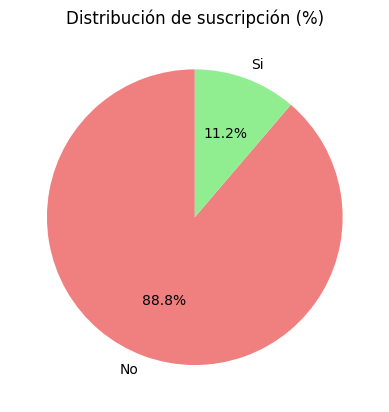

In [428]:
# Se evalua la efectividad de la campaña telefónica y vemos la tasa de suscripción global
y_distribution = df_final["y"].value_counts(normalize=True) * 100

y_distribution.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90,
    colors=["lightcoral", "lightgreen"]
)

#Visualización de resultado: Gráfico 1
plt.title("Distribución de suscripción (%)")
plt.ylabel("")
plt.show()

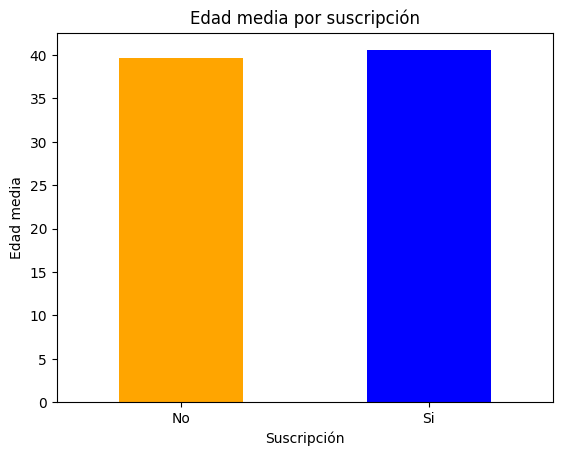

In [429]:
# Se Compara si los que se suscriben son más jóvenes o mayores.
df_final.groupby("y")["age"].mean().plot(
    kind="bar",
    color=["orange", "blue"]
)

#Visualización de resultado: Gráfico 2
plt.title("Edad media por suscripción")
plt.ylabel("Edad media")
plt.xlabel("Suscripción")
plt.xticks(rotation=0)
plt.show()

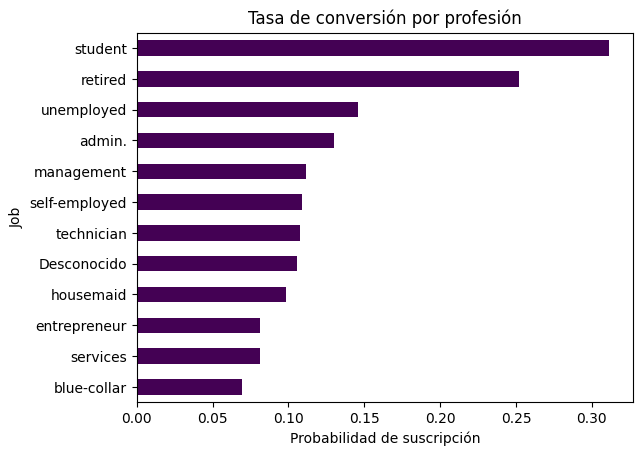

In [430]:
#Para facilitar los cálculos matemáticos se crea una nueva columna subscribed y se asigna valor 1 a Si y 0 a No
df_final["subscribed"] = df_final["y"].map({"Si": 1, "No": 0})

# Se determina que profesiones se convierten más
df_final.groupby("job")["subscribed"].mean() \
    .sort_values(ascending=True) \
    .plot(kind="barh", cmap="viridis")

#Visualización de resultado: Gráfico 3
plt.title("Tasa de conversión por profesión")
plt.xlabel("Probabilidad de suscripción")
plt.ylabel("Job")
plt.show()

/var/folders/22/4p4whbtn14jgjq0f3t2234yh0000gq/T/ipykernel_1296/797613219.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


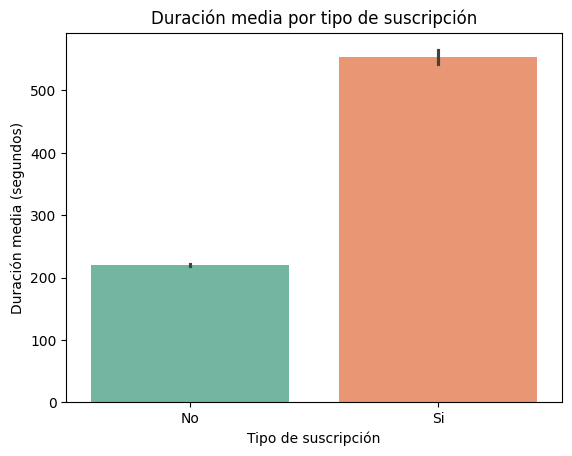

In [432]:
# Se determina la duración media en segundos de la última interacción con el cliente
df_final.groupby("y")["duration"].mean()

#Visualización de resultado: Gráfico 4
sns.barplot(
    data=df_final,
    x="y",
    y="duration",
    estimator="mean",
    palette="Set2"
)

plt.title("Duración media por tipo de suscripción")
plt.xlabel("Tipo de suscripción")
plt.ylabel("Duración media (segundos)")
plt.show()

/var/folders/22/4p4whbtn14jgjq0f3t2234yh0000gq/T/ipykernel_1296/3088738025.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


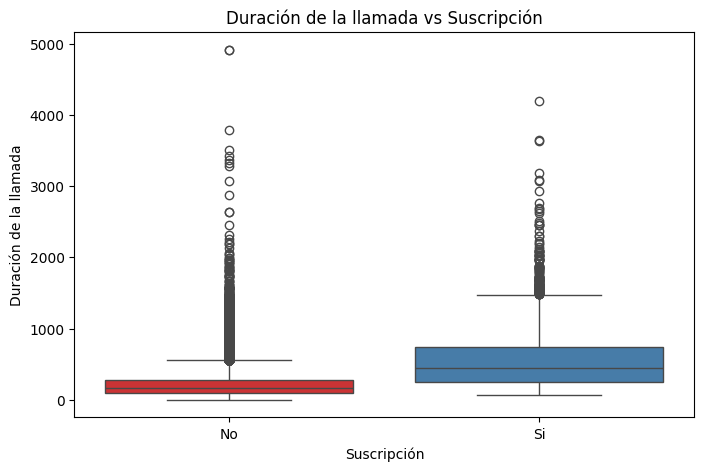

In [ ]:
# Se analiza si las llamadas exitosas tienen una duración media significativamente mayor
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_final,
    x="y",
    y="duration",
    palette="Set1"
)
#Visualización de resultado: Gráfico 5
plt.title("Duración de la llamada vs Suscripción")
plt.xlabel("Suscripción")
plt.ylabel("Duración de la llamada")


plt.show()




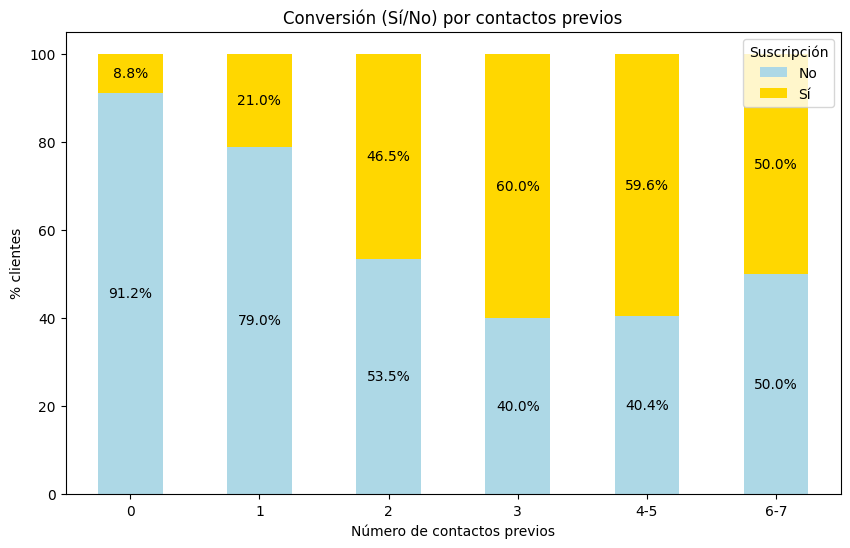

In [ ]:
# Se determina la tasa de suscripción (sí/no) según el número de contactos previos

# Se segmentan los datos
df_final["prev_bin"] = pd.cut(
    df_final["previous"],
    bins=[-1, 0, 1, 2, 3, 5, 7],
    labels=["0", "1", "2", "3", "4-5", "6-7"]
)

# Se calcula la distribución porcentual de la variable y (sí/no) dentro de cada segmento

prev_segment = (
    df_final.groupby("prev_bin")["y"]
    .value_counts(normalize=True)
    .unstack() * 100
)

#Visualización de resultado: Gráfico 6
ax = prev_segment.plot(
    kind="bar",
    stacked=True,
    color=["lightblue", "gold"],
    figsize=(10,6)
)

plt.title("Conversión (Sí/No) por contactos previos")
plt.ylabel("% clientes")
plt.xlabel("Número de contactos previos")
plt.xticks(rotation=0)
plt.legend(title="Suscripción", labels=["No", "Sí"])

# Se crea un bucle para añad¡r los porcentajes dentro de las barras
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", label_type="center")

plt.show()

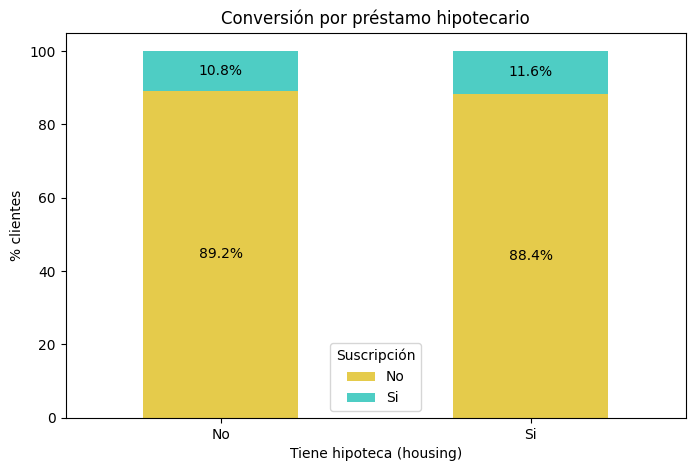

In [ ]:
# Se calcula el porcentaje de clientes que se suscriben o no dentro de cada grupo de housing (con y sin hipoteca).
housing_analysis = (
    df_final.groupby("housing")["y"]
    .value_counts(normalize=True)
    .unstack() * 100
)

# Se visualizan los datos
ax = housing_analysis.plot(
    kind="bar",
    stacked=True,
    color=["#E5CB4B", "#4ECDC4"],
    figsize=(8,5)
)

#Visualización de resultado: Gráfico 7
plt.title("Conversión por préstamo hipotecario")
plt.ylabel("% clientes")
plt.xlabel("Tiene hipoteca (housing)")
plt.legend(title="Suscripción")
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", label_type="center")

plt.show()

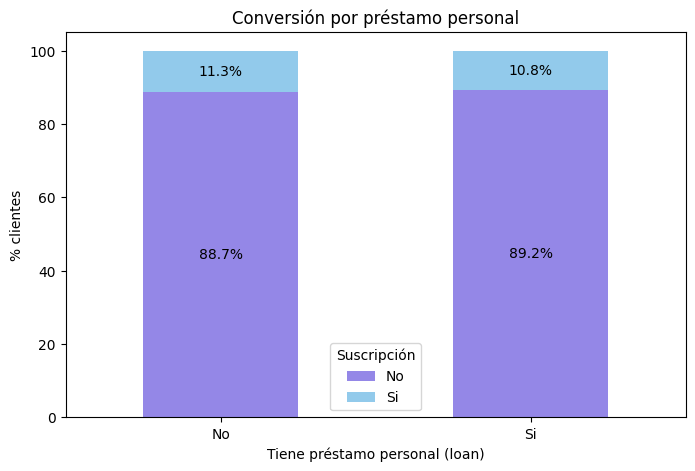

In [ ]:
## Se calcula la tasa conversión entre clientes con prestamo personal

loan_analysis = (
    df_final.groupby("loan")["y"]
    .value_counts(normalize=True)
    .unstack() * 100
)

ax = loan_analysis.plot(
    kind="bar",
    stacked=True,
    color=["#9487E7", "#92CAEB"],
    figsize=(8,5)
)

#Visualización de resultado: Gráfico 8
plt.title("Conversión por préstamo personal")
plt.ylabel("% clientes")
plt.xlabel("Tiene préstamo personal (loan)")
plt.xticks(rotation=0)
plt.legend(title="Suscripción")


for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", label_type="center")

plt.show()

/var/folders/22/4p4whbtn14jgjq0f3t2234yh0000gq/T/ipykernel_1296/688151664.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data_no, data_si], labels=["No suscribe", "Suscribe"])


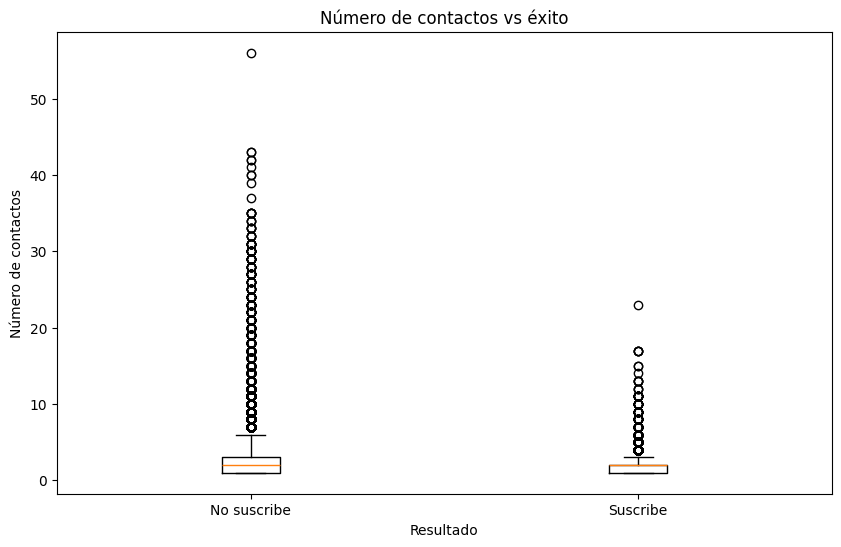

In [437]:
# Número de contactos entre clientes que suscriben y los que no.
data_si = df_final[df_final["y"] == "Si"]["campaign"]
data_no = df_final[df_final["y"] == "No"]["campaign"]

#Visualización de resultado: Gráfico 9
plt.figure(figsize=(10,6))

plt.boxplot([data_no, data_si], labels=["No suscribe", "Suscribe"])

plt.title("Número de contactos vs éxito")
plt.xlabel("Resultado")
plt.ylabel("Número de contactos")

plt.show()

# El número de intentos de llamada NO es un factor decisivo por sí solo.

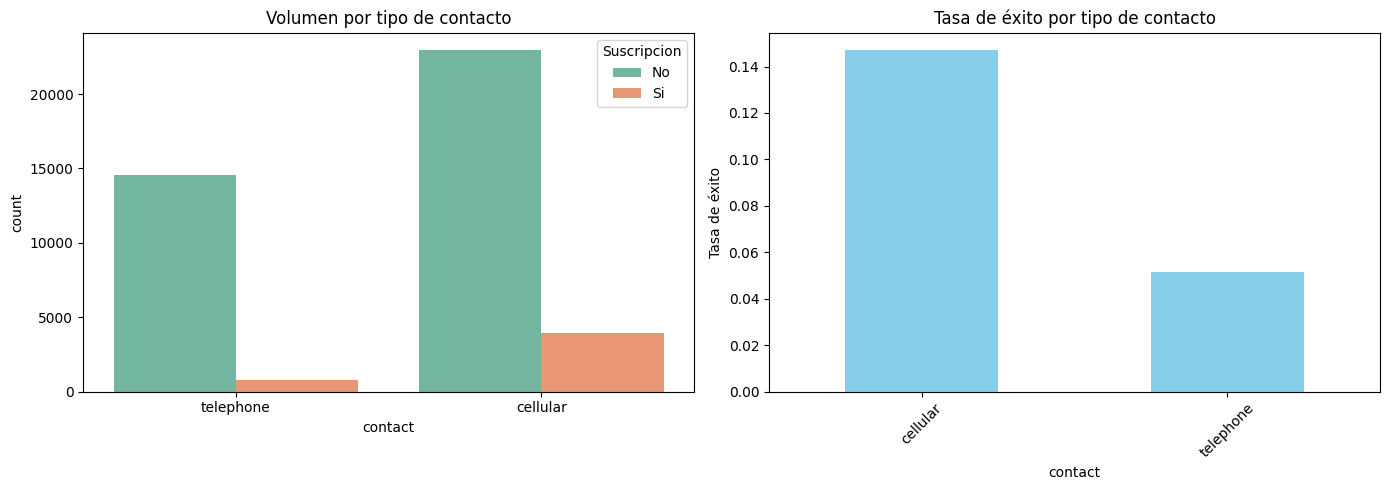

In [438]:
#Visualización de resultado: Gráfico 10
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Se identifica el volumen de cliente y su tasa de suscripcion segun el tipo de contacto
sns.countplot(
    data=df_final,
    x="contact",
    hue="y",
    palette="Set2",
    ax=axes[0]
    
)

axes[0].set_title("Volumen por tipo de contacto")
axes[0].legend(title="Suscripcion")

# Se determina la tasa de exito
df_final["success"] = (df_final["y"] == "Si").astype(int)

rate = df_final.groupby("contact")["success"].mean()

rate.plot(
    kind="bar",
    ax=axes[1],
    color="skyblue"
)

axes[1].set_title("Tasa de éxito por tipo de contacto")
axes[1].set_ylabel("Tasa de éxito")

# 👉 rotar etiquetas X
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

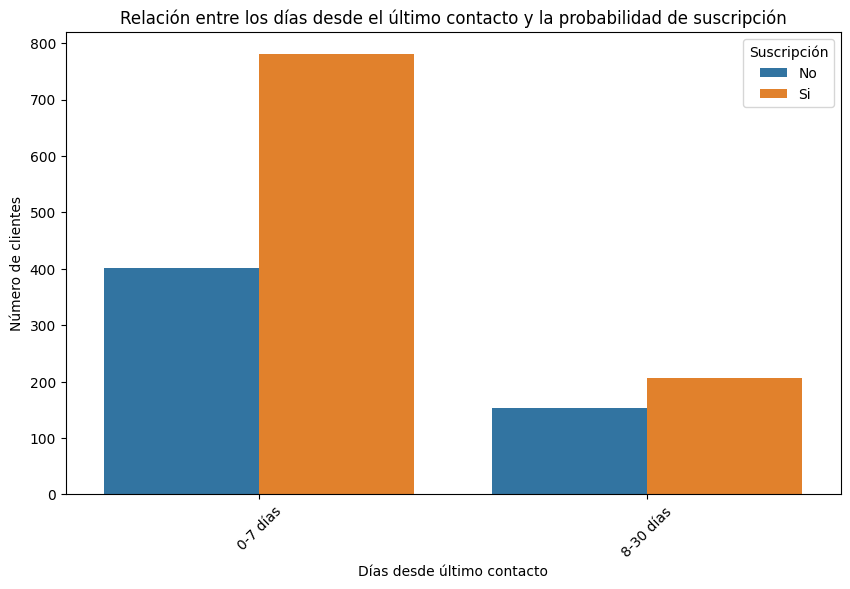

In [448]:
# La columna pdays tiene mas del 96%  999 como valor lo que en marketing tiende a significar que nunca fue contactado. Esa informacion es fundamental para distinguir entre clientes nuevos o que ya han sido contactados. 
# Por ese motivo se mantiene esa columna pero se reemplaza 999 por el valor o para que no distorsione los datos.
df_final["was_contacted"] = (df_final["pdays"] != 999).astype(int)
df_final["pdays_real"] = df_final["pdays"].replace(999, 0)

# Se crean grupos (segmentación) para los días reales de contacto
bins = [0, 7, 30]  # Ajustados para 0-7 y 8-30
labels = ['0-7 días', '8-30 días']
df_final['pdays_group'] = pd.cut(df_final['pdays_real'], bins=bins, labels=labels)

#Grafico que indica la relación entre días que han pasado desde que se contacto a un cliente durante la campaña actual con la tasa de suscripcion
#Visualización de resultado: Gráfico 11
plt.figure(figsize=(10,6))
sns.countplot(data=df_final, x='pdays_group', hue='y')

plt.title("Relación entre los días desde el último contacto y la probabilidad de suscripción")
plt.xlabel("Días desde último contacto")
plt.ylabel("Número de clientes")
plt.legend(title="Suscripción")
plt.xticks(rotation=45)

plt.show()

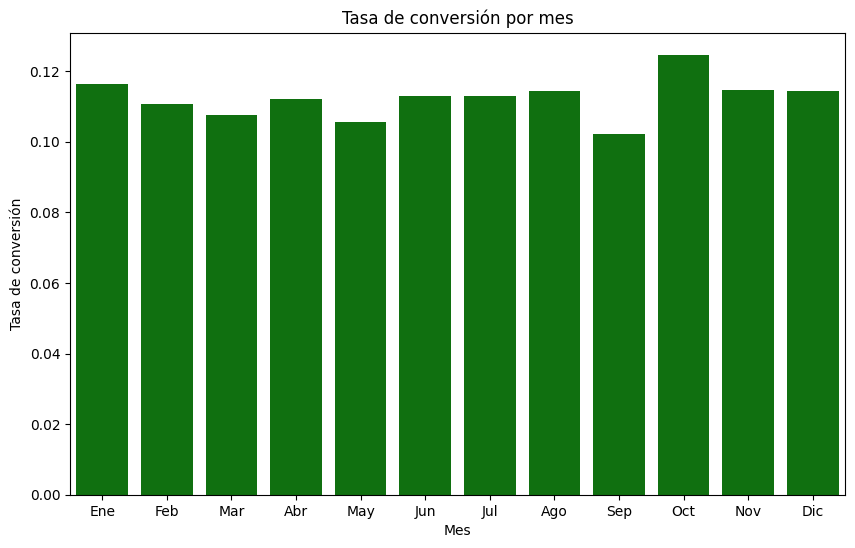

In [ ]:
# Se crea una variable numérica (y_num) a partir de la variable objetivo 'y'
# para poder realizar análisis estadísticos, correlaciones y visualizaciones
# donde la suscripción se representa como 1 (Sí) y 0 (No)
df_temp = df_final.assign(
    y_num = df_final["y"].map({"Si": 1, "No": 0})
)

# Se calcula la tasa de conversión por mes usando el dataset temporal
conversion_por_mes = (
    df_temp
    .groupby("contact_month")["y_num"]
    .mean()
)

# Visualización de resultado: Gráfico 12
plt.figure(figsize=(10,6))

sns.barplot(
    x=conversion_por_mes.index,
    y=conversion_por_mes.values,
    color="green"
)

plt.title("Tasa de conversión por mes")
plt.xlabel("Mes")
plt.ylabel("Tasa de conversión")

plt.xticks(
    ticks=range(len(conversion_por_mes)),
    labels=["Ene", "Feb", "Mar", "Abr", "May", "Jun", "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"]
)

plt.show()

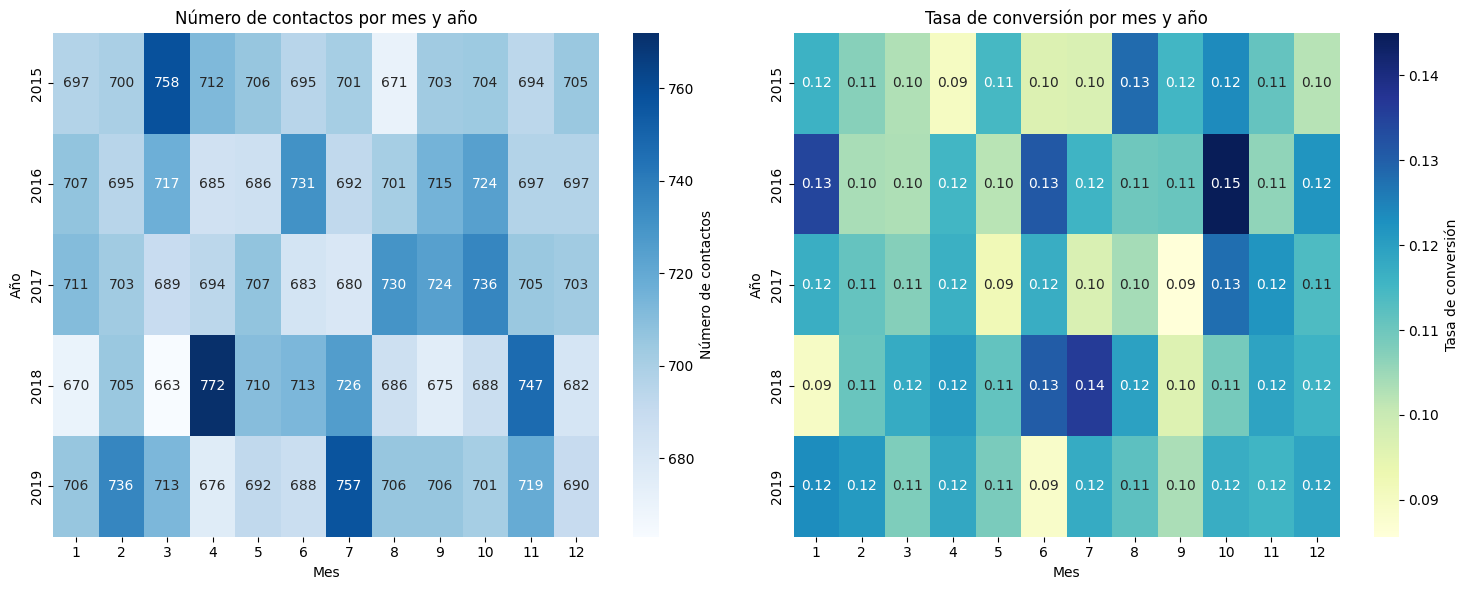

In [441]:
# Número de contactos por mes y año
contactos_por_mes_ano = (
    df_temp
    .groupby(['contact_year', 'contact_month'])
    .size()
    .unstack(fill_value=0)
)

# Tasa de conversión por mes y año
conversion_temporal = (
    df_temp
    .groupby(['contact_year', 'contact_month'])["y_num"]
    .mean()
    .unstack(fill_value=0)
)

#Visualización de resultado: Gráfico 13
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Heatmap 1: Contactos
sns.heatmap(
    contactos_por_mes_ano,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=ax1,
    cbar_kws={'label': 'Número de contactos'}
)

ax1.set_title("Número de contactos por mes y año")
ax1.set_xlabel("Mes")
ax1.set_ylabel("Año")

# Heatmap 2: Conversión
sns.heatmap(
    conversion_temporal,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    ax=ax2,
    cbar_kws={'label': 'Tasa de conversión'}
)

ax2.set_title("Tasa de conversión por mes y año")
ax2.set_xlabel("Mes")
ax2.set_ylabel("Año")

plt.tight_layout()
plt.show()

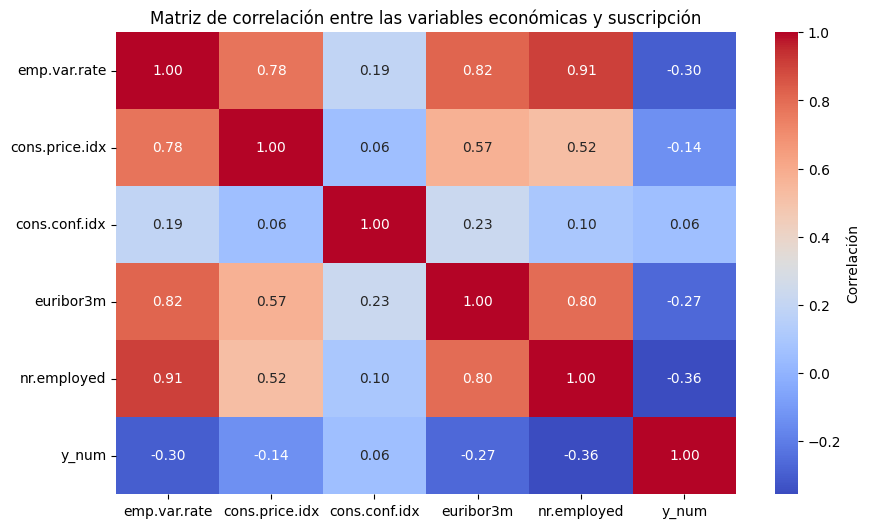

In [442]:
# Definir las variables económicas
variables_economicas = [
    "emp.var.rate",
    "cons.price.idx",
    "cons.conf.idx",
    "euribor3m",
    "nr.employed"
]

# Calcular la correlación (usando variable temporal)
correlacion = df_temp[variables_economicas + ["y_num"]].corr()

#Visualización de resultado de la matriz de correlación: Gráfico 14

plt.figure(figsize=(10, 6))
sns.heatmap(correlacion, annot=True, cmap="coolwarm", fmt=".2f", cbar_kws={'label': 'Correlación'})
plt.title("Matriz de correlación entre las variables económicas y suscripción")
plt.show()


/var/folders/22/4p4whbtn14jgjq0f3t2234yh0000gq/T/ipykernel_1296/4037941939.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_final, x='y', y='NumWebVisitsMonth', palette="Set2", showfliers=True)


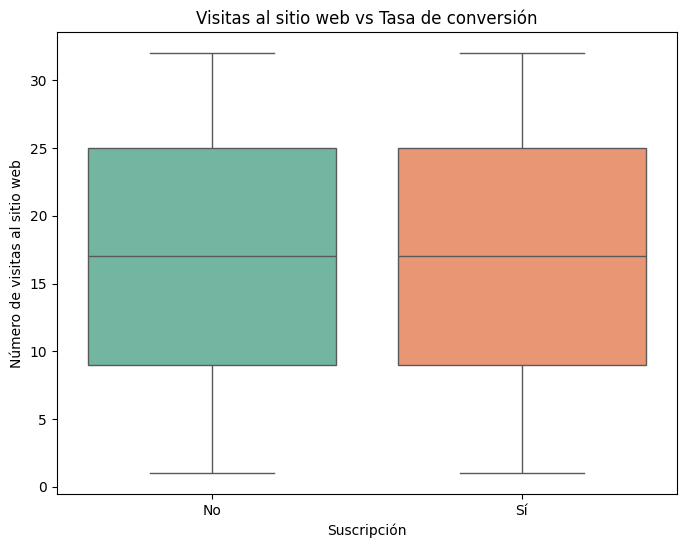

In [443]:
#Visualización de resultado: Gráfico 15: Comparación de visitas al sitio web según suscripción
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_final, x='y', y='NumWebVisitsMonth', palette="Set2", showfliers=True)

# Título y etiquetas
plt.title("Visitas al sitio web vs Tasa de conversión")
plt.xlabel("Suscripción")
plt.ylabel("Número de visitas al sitio web")
plt.xticks([0, 1], ['No', 'Sí'])

# Mostrar el gráfico
plt.show()

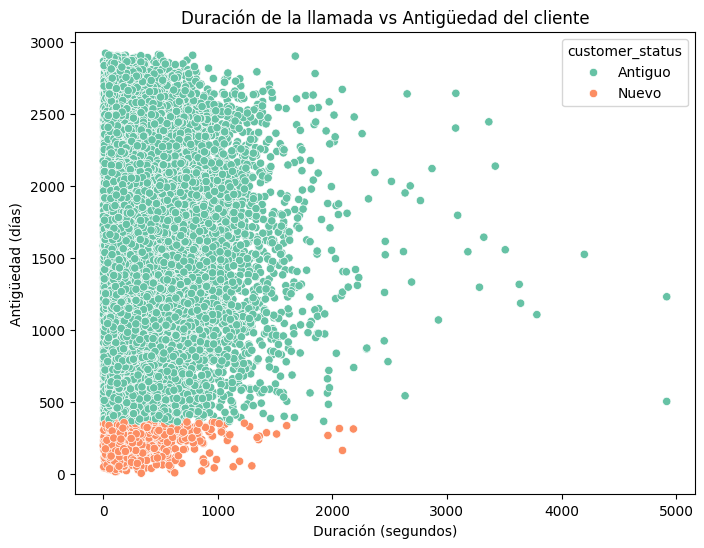

In [444]:
# Crear antigüedad en días (si no lo tienes ya)
df_final["customer_tenure_days"] = (
    df_final["date"] - df_final["Dt_Customer"]
).dt.days

# Crear segmentación
df_final["customer_status"] = df_final["customer_tenure_days"].apply(
    lambda x: "Nuevo" if x < 365 else "Antiguo"
)

#Visualización de resultado: Gráfico 16
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df_final,
    x="duration",
    y="customer_tenure_days",
    hue="customer_status",
    palette="Set2"
)

plt.title("Duración de la llamada vs Antigüedad del cliente")
plt.xlabel("Duración (segundos)")
plt.ylabel("Antigüedad (días)")
plt.show()

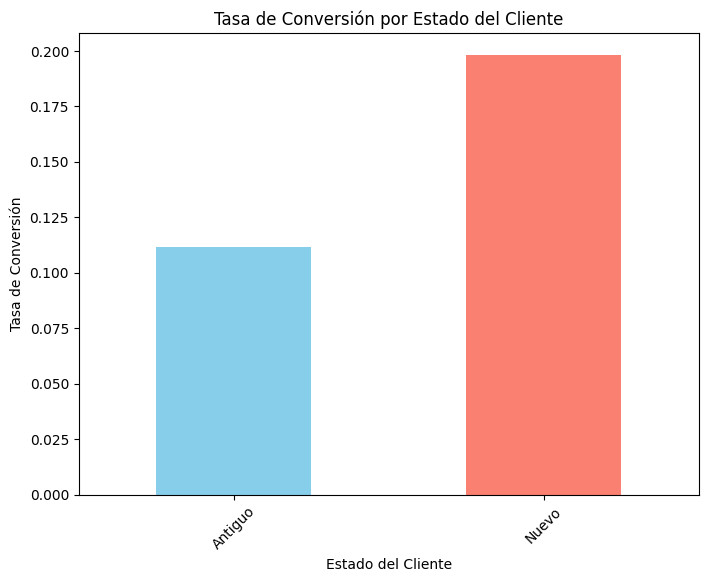

In [445]:
df_final["customer_status"] = df_final["customer_tenure_days"].apply(
    lambda x: "Nuevo" if x < 180 else "Antiguo"
)

conversion_rate = df_final.groupby("customer_status")["y"].apply(
    lambda x: (x == "Si").mean()
)
##Visualización de resultado: Gráfico 17
plt.figure(figsize=(8, 6))

conversion_rate.plot(kind="bar", color=["skyblue", "salmon"])

plt.title("Tasa de Conversión por Estado del Cliente")
plt.xlabel("Estado del Cliente")
plt.ylabel("Tasa de Conversión")
plt.xticks(rotation=45)

plt.show()